In [ ]:
!pip install --upgrade --quiet accelerate bitsandbytes transformers medmnist torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.9 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from medmnist import PneumoniaMNIST
from transformers import BitsAndBytesConfig, pipeline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
model_id = "google/medgemma-4b-it"

bnb_config = BitsAndBytesConfig(load_in_4bit=True)

pipe = pipeline(
    task="image-text-to-text",
    model=model_id,
    model_kwargs={
        "device_map": "auto",
        "torch_dtype": torch.bfloat16,
        "quantization_config": bnb_config,
    },
)

pipe.model.generation_config.do_sample = False
print("MedGemma loaded successfully")

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

MedGemma loaded successfully


In [ ]:
dataset = PneumoniaMNIST(split="test", download=True)

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.46MB/s]


In [ ]:
class PneumoniaResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.model.fc = nn.Linear(self.model.fc.in_features, 1)

    def forward(self, x):
        return self.model(x)

In [ ]:
cnn_model = PneumoniaResNet().to(device)

state_dict = torch.load("/content/resnet18_pneumonia.pth", map_location=device)
cnn_model.load_state_dict(state_dict)

cnn_model.eval()
print("Task-1 CNN loaded")

Task-1 CNN loaded


In [ ]:
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
from torchvision.transforms.functional import to_pil_image
import torch

def tensor_to_pil(img):
    """
    Safely convert image to PIL format whether input is:
    - torch.Tensor
    - numpy array
    - PIL.Image
    """
    if isinstance(img, Image.Image):
        return img.convert("RGB")

    if isinstance(img, torch.Tensor):
        if img.ndim == 3:
            img = img.squeeze(0)
        return to_pil_image(img).convert("RGB")

    # fallback (numpy)
    return Image.fromarray(img).convert("RGB")

In [ ]:
samples = []

for i in range(len(dataset)):
    img, label = dataset[i]
    label = int(label[0])
    pred = cnn_predict(img)

    samples.append({
        "img": img,
        "gt": label,
        "pred": pred,
        "misclassified": label != pred
    })

normal = [s for s in samples if s["gt"] == 0 and not s["misclassified"]][:5]
pneumonia = [s for s in samples if s["gt"] == 1 and not s["misclassified"]][:5]
misclassified = [s for s in samples if s["misclassified"]][:5]

selected = normal + pneumonia + misclassified
print("Total images selected:", len(selected))

Total images selected: 15


In [ ]:
system_instruction = "You are a senior radiologist."
user_prompt = (
    "Analyze this chest X-ray and provide:\n"
    "1. Key radiographic findings\n"
    "2. Impression\n"
    "3. Whether findings suggest pneumonia"
)

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


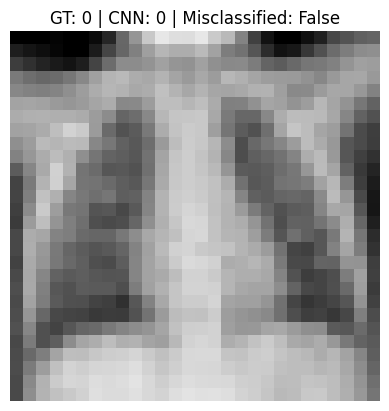

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   The image appears to show a normal lung field.
*   The heart size and mediastinal contours are within normal limits.
*   There is no obvious consolidation, pleural effusion, or pneumothorax.

**2. Impression:**

The chest X-ray is unremarkable.

**3. Whether findings suggest pneumonia:**

Based on this single image, there is no evidence to suggest pneumonia.

**Important Considerations:**

*   This is a single image. A full chest X-ray series (PA and lateral views) is necessary for a complete evaluation.
*   The patient's clinical presentation is crucial. The X-ray findings must be correlated with the patient's symptoms, history, and physical examination.
*   This analysis is based solely on the provided image and does not constitute a definitive diagnosis.

**Disclaimer:** This analysis is for informational purposes only and should not be considered a substitute for a professional medical ev

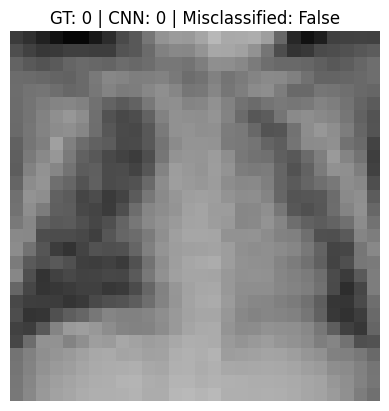

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   **Lung Fields:** The lung fields appear relatively clear. There is no obvious consolidation, effusion, or significant mass.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum appears unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, it is **not possible to definitively rule out pneumonia**. The lung fields appear clear, but a subtle pneumonia might not be visible on a single view, especially if it's early in its course.

**Important Considerations:**

*   **Clinical Context:** The interpretation of a chest X-ray *always* depends on the patient's clinical presentation, symptoms, and medical history.
*   **Further Imaging:** If there is a clinical suspicion for pne

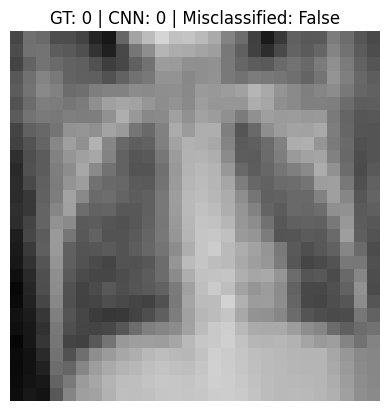

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray.

**1. Key Radiographic Findings:**

*   The image appears to show a normal heart size and shape.
*   The mediastinum (the space between the lungs containing the heart, great vessels, and trachea) appears unremarkable.
*   The lung fields are clear, with no obvious consolidation, effusions, or masses.
*   The costophrenic angles are sharp.

**2. Impression:**

The chest X-ray is essentially normal. There are no acute findings to suggest pneumonia or other significant cardiopulmonary pathology.

**3. Whether Findings Suggest Pneumonia:**

No, the findings do not suggest pneumonia. The lungs are clear, and there is no evidence of consolidation, which is a hallmark of pneumonia.

**Important Considerations:**

*   This is a single image. A full chest X-ray would include both PA and lateral views, as well as a PA and lateral with a marker on the patient's chest.
*   The quality of the image is not ideal for a definitive diagnosis.
*   T

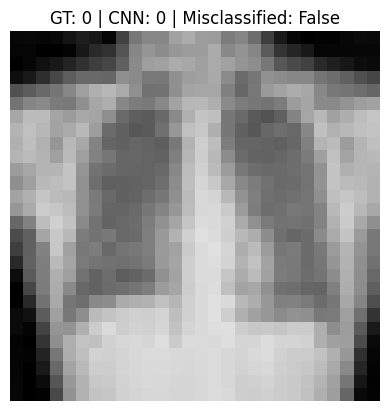

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray. Here's my analysis:

**1. Key Radiographic Findings:**

*   **Lung Fields:** The lung fields appear clear bilaterally. There is no obvious consolidation, effusion, or pneumothorax.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum is unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, there is **no evidence** to suggest pneumonia. The lung fields are clear, and there are no findings typical of pneumonia such as consolidation, infiltrates, or pleural effusions.

**Important Considerations:**

*   **This is a single image.** A complete evaluation requires a full chest X-ray with appropriate positioning and potentially additional views (e.g., PA, lateral, and possibly a decubitus view) to rule out subtle f

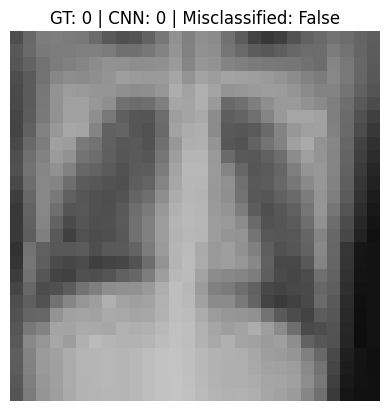

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray. Here's my analysis:

**1. Key Radiographic Findings:**

*   **Lung Fields:** The lung fields appear clear bilaterally. There is no obvious consolidation, effusion, or pneumothorax.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum is unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, there is **no evidence** to suggest pneumonia. The lung fields are clear, and there are no findings typical of pneumonia such as consolidation, infiltrates, or pleural effusions.

**Important Considerations:**

*   **This is a single image.** A complete evaluation requires a full chest X-ray with appropriate positioning and potentially additional views (e.g., PA, lateral, and possibly a decubitus view) to rule out subtle a

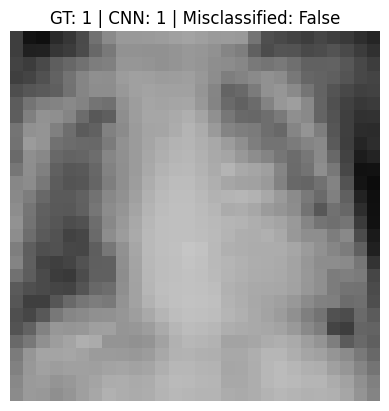

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray.

**1. Key Radiographic Findings:**

*   **Overall Lung Fields:** The lung fields appear clear. There is no obvious consolidation, effusion, or pneumothorax.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum appears unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single view, there is **no evidence** to suggest pneumonia. The lung fields are clear, and there are no findings typical of pneumonia such as consolidation, infiltrates, or pleural effusions.

**Important Considerations:**

*   **This is a single view.** A full chest X-ray (PA and lateral views) is always preferred for accurate assessment.
*   **Clinical Context is Crucial:** The interpretation of any chest X-ray must be done in the context of the patient

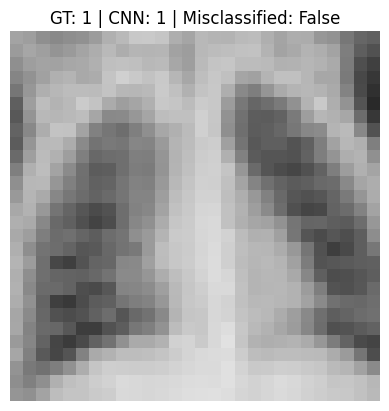

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray. Here's my analysis:

**1. Key Radiographic Findings:**

*   The image shows a normal lung field.
*   The heart size appears within normal limits.
*   The mediastinum is unremarkable.
*   The bony structures of the rib cage are intact.

**2. Impression:**

The chest X-ray is normal.

**3. Whether findings suggest pneumonia:**

No, the current chest X-ray does not suggest pneumonia. There are no findings to indicate an infectious process in the lungs.

**Important Considerations:**

*   This is a single image. A full chest X-ray would include PA and lateral views, as well as a possible AP view.
*   The patient's clinical presentation is crucial. The X-ray findings must be correlated with the patient's symptoms, history, and physical examination.
*   If the patient has a fever, cough, or other signs of infection, further investigation (e.g., CT scan, sputum culture) may be warranted.

**Disclaimer:** This analysis is based solely on t

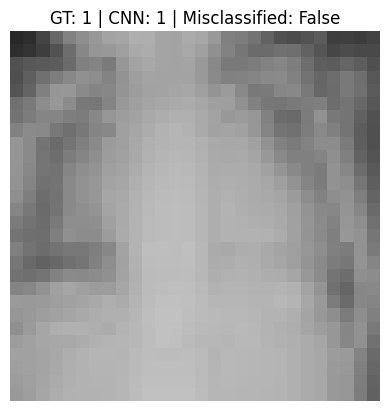

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   The image appears to show a normal heart size and shape.
*   The mediastinum (the space between the lungs containing the heart, great vessels, and trachea) appears unremarkable.
*   The lung fields are clear, with no obvious consolidation, effusions, or masses.
*   The costophrenic angles are sharp.

**2. Impression:**

The chest X-ray is unremarkable. There are no acute findings to suggest pneumonia or other significant cardiopulmonary pathology.

**3. Whether Findings Suggest Pneumonia:**

No, the findings do not suggest pneumonia. The lungs are clear, and there is no evidence of consolidation, which is a hallmark of pneumonia.

**Important Considerations:**

*   **Image Quality:** The image quality is not ideal for a detailed assessment. It is difficult to make a definitive diagnosis based on this single image alone.
*   **Clinical Context:** The interpretation of any chest X-ray should al

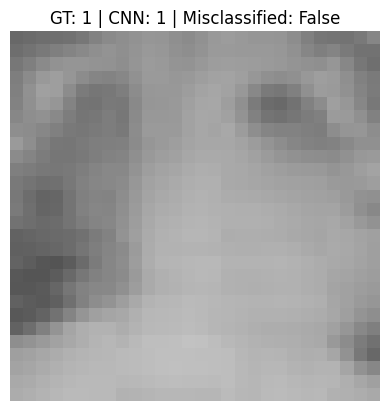

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

I am unable to analyze the image you sent. I am a text-based AI and cannot process images.

To provide a proper analysis, I would need to see the image in a format that allows me to interpret it.

If you can describe the image to me, I can provide a general impression.





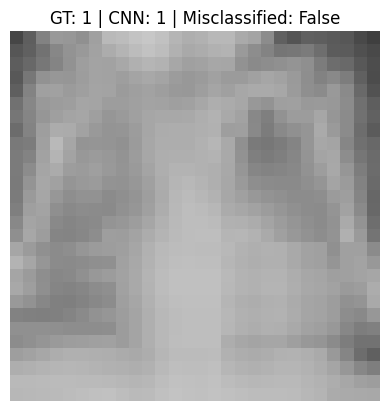

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   **Overall:** The image appears to be a standard PA (posterior-anterior) chest radiograph.
*   **Lung Fields:** The lung fields are clear, with no obvious consolidation, effusions, or masses.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum is unremarkable.
*   **Bones:** The bony structures of the ribs and spine are intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities. The lung fields are clear, and there is no evidence of pneumonia, pleural effusion, or other significant pathology.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, **no**, the findings do not suggest pneumonia. The lung fields are clear, which is the expected appearance in the absence of pneumonia.

**Important Considerations:**

*   **This is a single image.** A complete evaluation requires a full chest X-ray with proper position

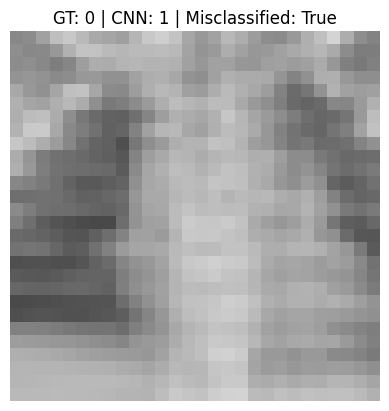

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

I am unable to analyze the image you sent. I am a text-based AI and cannot process images.

To provide a proper analysis, I would need to see the image in a format that allows me to interpret it.

**To get a proper analysis, you will need to:**

1.  **Save the image as a standard image format** (e.g., JPEG, PNG, TIFF).
2.  **Upload the image to a platform that allows image analysis** (e.g., a radiology image viewer with AI capabilities, or a medical image analysis service).
3.  **Provide the image to a radiologist** who can then perform the analysis.

Once I have the image, I can provide a detailed analysis including:

*   **Key radiographic findings:** This would include descriptions of the lung fields, heart size, mediastinum, and any other relevant structures.
*   **Impression:** This is a summary of the findings and a potential diagnosis or differential diagnosis.
*   **Whether findings suggest pneumonia:** This would be based on the specific findings and the clin

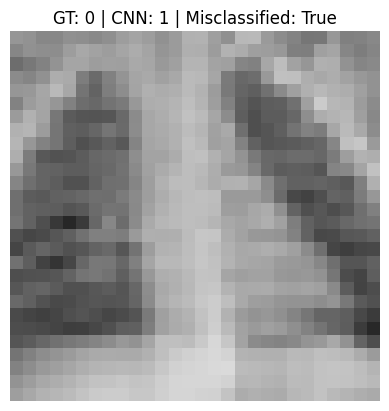

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   **Lung Fields:** The lung fields appear relatively clear. There is no obvious consolidation, effusion, or significant mass.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum appears unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, it is **not possible to definitively rule out pneumonia**. The lung fields appear clear, but a subtle pneumonia might not be visible on a single view, especially if it's early in its course.

**Important Considerations:**

*   **Clinical Context:** The interpretation of a chest X-ray is always best when considered in the context of the patient's clinical presentation, symptoms, and medical history.
*   **Further Imaging:** If there is

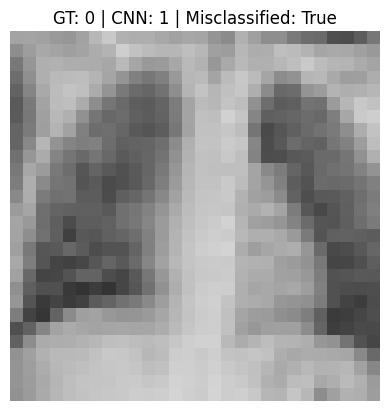

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've analyzed the chest X-ray.

**1. Key Radiographic Findings:**

*   The image is a single view of the chest, with the right side appearing more prominent.
*   The lung fields appear relatively clear, with no obvious consolidation, effusions, or masses.
*   The heart size appears normal.
*   The mediastinum appears normal in width and alignment.

**2. Impression:**

Based on this single view, there are no obvious acute findings to suggest pneumonia. However, a single view is insufficient to rule out subtle abnormalities.

**3. Whether Findings Suggest Pneumonia:**

No, the findings do not strongly suggest pneumonia. A single view is not adequate to rule out pneumonia.

**Important Considerations:**

*   **Single View:** This is a single view, which is not ideal for evaluating the lungs. A PA and lateral view are preferred for a complete assessment.
*   **Clinical Context:** The interpretation of any chest X-ray must be done in the context of the patient's clin

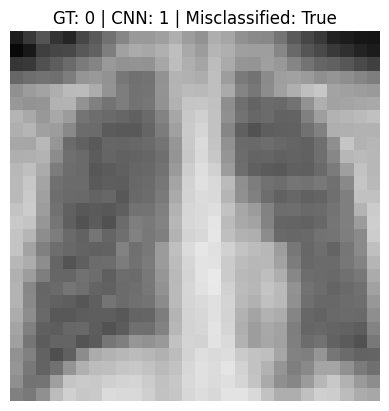

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray. Here's my analysis:

**1. Key Radiographic Findings:**

*   **Lung Fields:** The lung fields appear clear, with no obvious consolidation, effusions, or masses.
*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum appears unremarkable.
*   **Bones:** The visualized bony structures (ribs, clavicles) appear intact.

**2. Impression:**

The chest X-ray shows no acute abnormalities.

**3. Whether Findings Suggest Pneumonia:**

Based on this single image, there is **no evidence** to suggest pneumonia. The lung fields are clear, and there are no findings typical of pneumonia such as consolidation, infiltrates, or pleural effusions.

**Important Considerations:**

*   **This is a single image.** A complete evaluation requires a full chest X-ray with proper positioning and potentially additional views (e.g., PA, lateral, and possibly a decubitus view) to rule out subtle abnormalities.
*   **C

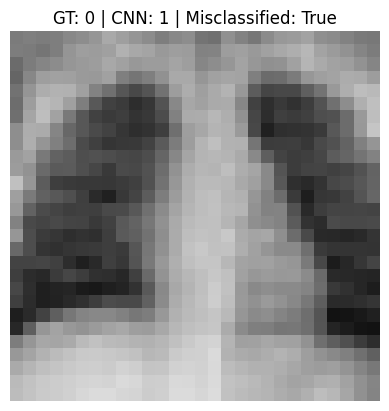

MEDGEMMA REPORT:

Okay, I've reviewed the chest X-ray.

**1. Key Radiographic Findings:**

*   The image appears to show a normal lung field.
*   There are no obvious signs of consolidation, effusion, or pneumothorax.
*   The heart size and mediastinal contours are within normal limits.

**2. Impression:**

The chest X-ray is unremarkable.

**3. Whether findings suggest pneumonia:**

Based on this single image, there is no evidence to suggest pneumonia.

**Important Considerations:**

*   This is a single image. A full chest X-ray would include both PA and lateral views, as well as a frontal view.
*   The patient's clinical history is crucial. The X-ray findings must be interpreted in the context of the patient's symptoms, signs, and medical history.
*   This interpretation is based solely on the provided image.

**Disclaimer:** This interpretation is for informational purposes only and should not be considered a definitive diagnosis. A proper diagnosis requires a complete evaluation b

In [ ]:
for i, s in enumerate(selected):
    image = tensor_to_pil(s["img"])

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_instruction}]
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image", "image": image}
            ]
        }
    ]

    output = pipe(text=messages, max_new_tokens=300)
    report = output[0]["generated_text"][-1]["content"]

    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"GT: {s['gt']} | CNN: {s['pred']} | Misclassified: {s['misclassified']}"
    )
    plt.show()

    print("MEDGEMMA REPORT:\n")
    print(report)
    print("\n" + "="*90 + "\n")